Prior Mean: 2.0
Likelihood Mean: 3.5
Calculated Posterior Mean: 3.20
Calculated Posterior Std Dev: 0.27


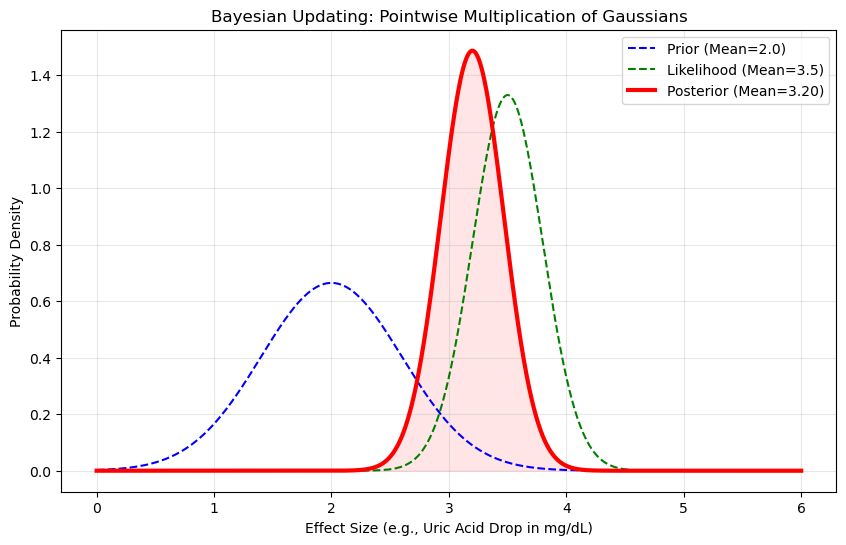

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the x-axis: The "Effect" (e.g., Uric Acid drop in mg/dL)
x = np.linspace(0, 6, 1000)

# 2. Prior: Initial belief (Mean=2.0, Std Dev=0.6)
# Represented as a wider, flatter curve (less certain)
prior_mean = 2.0
prior_std = 0.6
prior_pdf = norm.pdf(x, prior_mean, prior_std)

# 3. Likelihood: New trial data (Mean=3.5, Std Dev=0.3)
# Represented as a sharper curve (more certain/more patients)
like_mean = 3.5
like_std = 0.3
likelihood_pdf = norm.pdf(x, like_mean, like_std)

# 4. Posterior: Pointwise multiplication
# Note: After multiplying, we must normalize so the total area = 1
posterior_raw = prior_pdf * likelihood_pdf
posterior_pdf = posterior_raw / np.trapezoid(posterior_raw, x)

# 5. Theoretical Check (Using closed-form Gaussian update formulas)
# The new variance is the inverse of the sum of the precisions
post_var = 1 / (1/prior_std**2 + 1/like_std**2)
post_std = np.sqrt(post_var)
# The new mean is a weighted average of the prior and likelihood means
post_mean = (prior_mean/prior_std**2 + like_mean/like_std**2) * post_var

print(f"Prior Mean: {prior_mean}")
print(f"Likelihood Mean: {like_mean}")
print(f"Calculated Posterior Mean: {post_mean:.2f}")
print(f"Calculated Posterior Std Dev: {post_std:.2f}")

# Visualizing the Update
plt.figure(figsize=(10, 6))
plt.plot(x, prior_pdf, 'b--', label=f'Prior (Mean={prior_mean})')
plt.plot(x, likelihood_pdf, 'g--', label=f'Likelihood (Mean={like_mean})')
plt.plot(x, posterior_pdf, 'r-', linewidth=3, label=f'Posterior (Mean={post_mean:.2f})')
plt.fill_between(x, posterior_pdf, color='red', alpha=0.1)

plt.title('Bayesian Updating: Pointwise Multiplication of Gaussians')
plt.xlabel('Effect Size (e.g., Uric Acid Drop in mg/dL)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
